In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import os
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
day1_prices = pd.read_csv("/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Cleaned_Data/day1_prices.csv")
day1_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread
0,-1,0,TOMATOES,4999,5,4998,15,5013,5,5014,15,5006.0,0.0,14
1,-1,0,EMERALDS,9992,14,9990,29,10008,14,10010,29,10000.0,0.0,16
2,-1,100,EMERALDS,9992,11,9990,22,10008,11,10010,22,10000.0,0.0,16
3,-1,100,TOMATOES,5000,8,4998,21,5013,8,5014,21,5006.5,0.0,13
4,-1,200,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0,16


In [5]:
day2_prices = pd.read_csv("/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Cleaned_Data/day2_prices.csv")
day2_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread
0,-2,0,EMERALDS,9992,11,9990,25,10008,11,10010,25,10000.0,0.0,16
1,-2,0,TOMATOES,4993,7,4992,17,5007,7,5008,17,5000.0,0.0,14
2,-2,100,TOMATOES,4998,5,4993,7,5007,7,5008,16,5002.5,0.0,9
3,-2,100,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0,16
4,-2,200,TOMATOES,4994,6,4993,20,5008,6,5009,20,5001.0,0.0,14


In [6]:
tomatoes1 = day1_prices[day1_prices['product'] == 'TOMATOES']

tomatoes1.select_dtypes(include='number').agg(['mean', 'std', 'min', 'max']).T

,mean,std,min,max
day,-1.00000,0.000000,-1.0,-1.0
timestamp,499950.00000,288689.567991,0.0,999900.0
bid_price_1,4971.08010,14.581761,4941.0,5008.0
bid_volume_1,7.45390,1.796886,2.0,12.0
bid_price_2,4969.66730,14.524411,4940.0,5001.0
bid_volume_2,19.57500,3.885960,5.0,25.0
ask_price_1,4984.05540,14.627875,4950.0,5016.0
ask_volume_1,7.46480,1.799246,1.0,12.0
ask_price_2,4985.50960,14.565237,4956.0,5017.0
ask_volume_2,19.59210,3.885644,5.0,25.0


In [7]:
tomatoes2 = day2_prices[day2_prices['product'] == 'TOMATOES']

tomatoes2.select_dtypes(include='number').agg(['mean', 'std', 'min', 'max']).T

,mean,std,min,max
day,-2.0000,0.000000,-2.0,-2.0
timestamp,499950.0000,288689.567991,0.0,999900.0
bid_price_1,5001.4159,10.299754,4982.0,5032.0
bid_volume_1,7.4281,1.787666,2.0,12.0
bid_price_2,5000.0064,10.248818,4981.0,5027.0
bid_volume_2,19.5823,3.899044,3.0,25.0
ask_price_1,5014.4811,10.352283,4991.0,5042.0
ask_volume_1,7.4253,1.786824,2.0,12.0
ask_price_2,5015.9359,10.276583,4997.0,5043.0
ask_volume_2,19.5835,3.881718,5.0,25.0


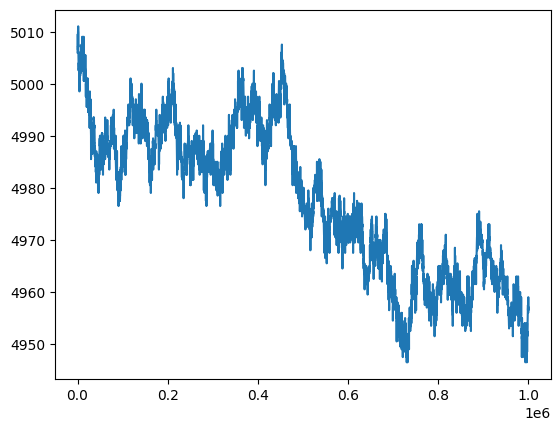

In [8]:
plt.plot(tomatoes1['timestamp'], tomatoes1['mid_price'], label='Day 1')

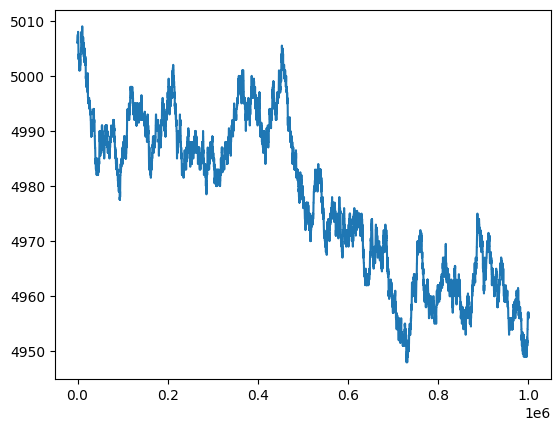

In [9]:
tomatoes1['mid_price_l2'] = (tomatoes1['bid_price_2'] + tomatoes1['ask_price_2'])/2

plt.plot(tomatoes1['timestamp'], tomatoes1['mid_price_l2'], label='Day 1 L2')

In [10]:
# Standard Deviation of the 1-tick price changes
sigma_l1 = tomatoes1['mid_price'].diff().std()
sigma_l2 = tomatoes1['mid_price_l2'].diff().std()

print(f"L1 Noise (Sigma): {sigma_l1}")
print(f"L2 Noise (Sigma): {sigma_l2}")

L1 Noise (Sigma): 1.3371550337622122
L2 Noise (Sigma): 0.6690033637425896


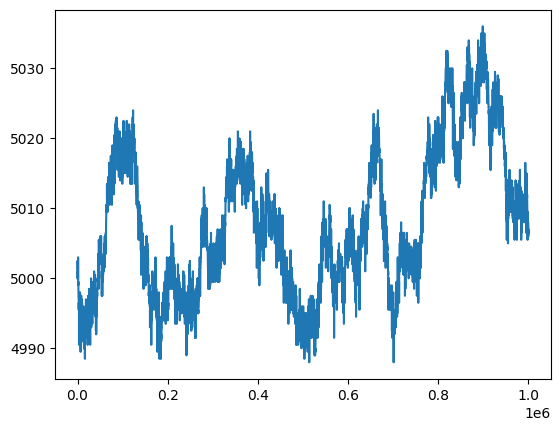

In [11]:
plt.plot(tomatoes2['timestamp'], tomatoes2['mid_price'], label='Day 2')

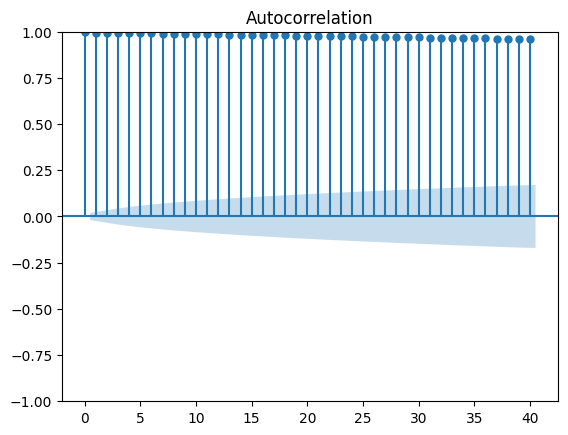

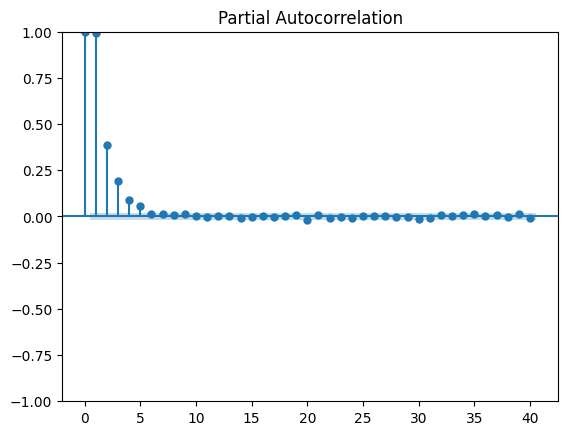

In [12]:
plot_acf(tomatoes1['mid_price'], lags=40)
plot_pacf(tomatoes1['mid_price'], lags=40)

plt.show()

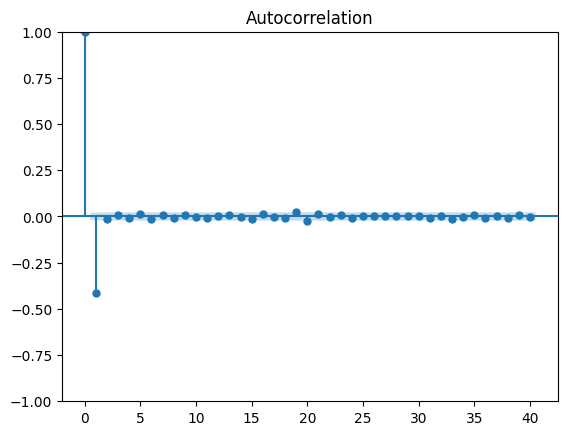

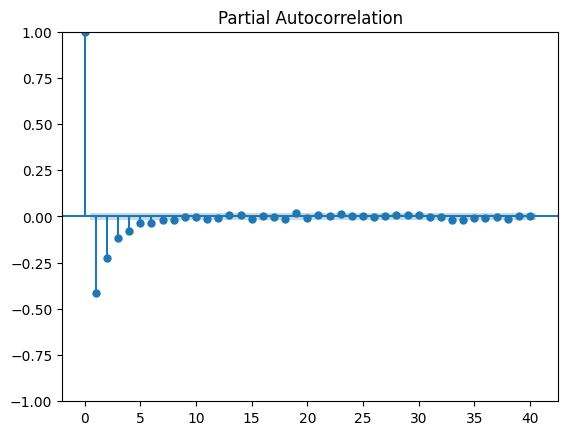

In [13]:
tomatoes1_d = tomatoes1['mid_price'].diff()

tomatoes1_d.dropna(inplace=True)

plot_acf(tomatoes1_d, lags=40)
plot_pacf(tomatoes1_d, lags=40)

plt.show()

<Axes: >

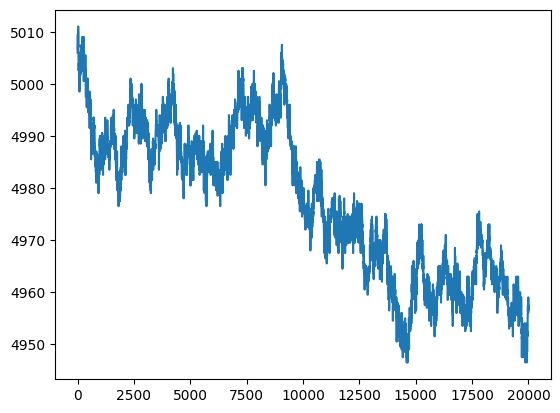

In [48]:
tomatoes1['mid_price'].plot()

<Axes: >

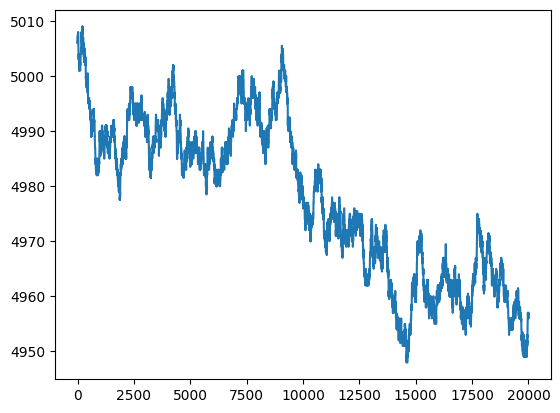

In [49]:
tomatoes1['mid_price_l2'].plot()

In [14]:
result = adfuller(tomatoes1_d)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -43.3393408313227
p-value: 0.0


In [15]:
tomatoes1_d.autocorr(lag=1)

np.float64(-0.4124796413963818)

In [16]:
tomatoes1

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread,mid_price_l2
0,-1,0,TOMATOES,4999,5,4998,15,5013,5,5014,15,5006.0,0.0,14,5006.0
3,-1,100,TOMATOES,5000,8,4998,21,5013,8,5014,21,5006.5,0.0,13,5006.0
5,-1,200,TOMATOES,5000,10,4999,20,5013,10,5015,20,5006.5,0.0,13,5007.0
6,-1,300,TOMATOES,5000,9,4999,21,5014,9,5015,21,5007.0,0.0,14,5007.0
8,-1,400,TOMATOES,5000,5,4999,20,5014,5,5015,20,5007.0,0.0,14,5007.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19990,-1,999500,TOMATOES,4955,5,4950,10,4963,10,4964,23,4959.0,0.0,8,4957.0
19993,-1,999600,TOMATOES,4955,5,4949,6,4963,6,4964,18,4959.0,0.0,8,4956.5
19994,-1,999700,TOMATOES,4950,10,4948,16,4963,10,4964,16,4956.5,0.0,13,4956.0
19997,-1,999800,TOMATOES,4951,6,4949,18,4964,6,4965,18,4957.5,0.0,13,4957.0


In [17]:
tomatoes1['bid_volume_1'].value_counts()

bid_volume_1
10    1663
9     1659
5     1643
6     1640
7     1635
8     1593
3       52
2       48
4       38
11      18
12      11
Name: count, dtype: int64

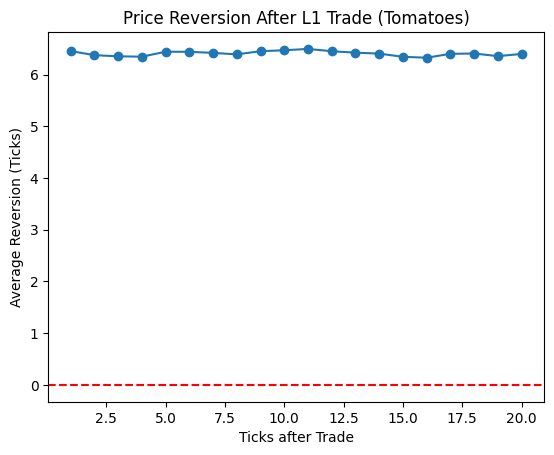

Average Reversion at 5 ticks: 6.4433


In [18]:
trades = pd.read_csv('/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Data/Round_0/trades_round_0_day_-1.csv', sep=';')
tomatoes_trades = trades[trades['symbol'] == 'TOMATOES']

combined = pd.merge_asof(tomatoes_trades.sort_values('timestamp'), 
                         tomatoes1.sort_values('timestamp'), 
                         on='timestamp', 
                         direction='backward')


tomatoes1['mid_l1'] = (tomatoes1['bid_price_1'] + tomatoes1['ask_price_1']) / 2

def calculate_reversion(lookahead):
    tomatoes1[f'mid_future_{lookahead}'] = tomatoes1['mid_l1'].shift(-lookahead)
    
    # Merge this future info into our trade list
    temp_combined = pd.merge_asof(combined, 
                                  tomatoes1[['timestamp', f'mid_future_{lookahead}']], 
                                  on='timestamp', 
                                  direction='backward')


    temp_combined['is_buy'] = temp_combined['price'] >= temp_combined['ask_price_1']
    temp_combined['is_sell'] = temp_combined['price'] <= temp_combined['bid_price_1']
    
    # Calculate 'Profitability' of the move (Price change relative to trade side)
    temp_combined['reversion_amt'] = 0.0
    # For Buys: (Trade Price - Future Mid) -> Positive means price fell back
    temp_combined.loc[temp_combined['is_buy'], 'reversion_amt'] = \
        temp_combined['price'] - temp_combined[f'mid_future_{lookahead}']
    # For Sells: (Future Mid - Trade Price) -> Positive means price rose back
    temp_combined.loc[temp_combined['is_sell'], 'reversion_amt'] = \
        temp_combined[f'mid_future_{lookahead}'] - temp_combined['price']
        
    return temp_combined['reversion_amt'].mean()

# Run the test for a window of 1 to 20 ticks
results = {i: calculate_reversion(i) for i in range(1, 21)}

# 5. Visualization
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.title("Price Reversion After L1 Trade (Tomatoes)")
plt.xlabel("Ticks after Trade")
plt.ylabel("Average Reversion (Ticks)")
plt.axhline(0, color='red', linestyle='--')
plt.show()

print(f"Average Reversion at 5 ticks: {results[5]:.4f}")

In [19]:
results

{1: np.float64(6.456264775413712),
 2: np.float64(6.377068557919622),
 3: np.float64(6.3546099290780145),
 4: np.float64(6.347517730496454),
 5: np.float64(6.443262411347518),
 6: np.float64(6.442080378250591),
 7: np.float64(6.42080378250591),
 8: np.float64(6.392434988179669),
 9: np.float64(6.453900709219858),
 10: np.float64(6.471631205673759),
 11: np.float64(6.497635933806147),
 12: np.float64(6.452718676122932),
 13: np.float64(6.425531914893617),
 14: np.float64(6.40661938534279),
 15: np.float64(6.3451536643026),
 16: np.float64(6.3274231678487),
 17: np.float64(6.40307328605201),
 18: np.float64(6.408983451536643),
 19: np.float64(6.358156028368795),
 20: np.float64(6.400709219858156)}

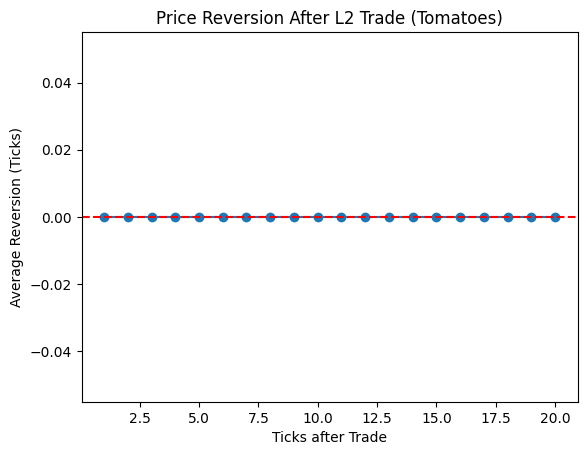

Average Reversion at 5 ticks: 0.0000


In [20]:
trades = pd.read_csv('/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Data/Round_0/trades_round_0_day_-1.csv', sep=';')
tomatoes_trades = trades[trades['symbol'] == 'TOMATOES']

combined = pd.merge_asof(tomatoes_trades.sort_values('timestamp'), 
                         tomatoes1.sort_values('timestamp'), 
                         on='timestamp', 
                         direction='backward')

# We want to see where the MID PRICE goes after a trade happens
tomatoes1['mid_l2'] = (tomatoes1['bid_price_2'] + tomatoes1['ask_price_2']) / 2

def calculate_reversion(lookahead):
    # Shift the mid price back to see 'future' mid relative to current trade
    tomatoes1[f'mid_future_{lookahead}_l2'] = tomatoes1['mid_l2'].shift(-lookahead)
    
    # Merge this future info into our trade list
    temp_combined = pd.merge_asof(combined, 
                                  tomatoes1[['timestamp', f'mid_future_{lookahead}_l2']], 
                                  on='timestamp', 
                                  direction='backward')

    
    # Identify if trade was a Buy or Sell based on L2 prices
    temp_combined['is_buy'] = temp_combined['price'] >= temp_combined['ask_price_2']
    temp_combined['is_sell'] = temp_combined['price'] <= temp_combined['bid_price_2']
    
    # Calculate 'Profitability' of the move (Price change relative to trade side)
    temp_combined['reversion_amt'] = 0.0
    # For Buys: (Trade Price - Future Mid) -> Positive means price fell back
    temp_combined.loc[temp_combined['is_buy'], 'reversion_amt'] = \
        temp_combined['price'] - temp_combined[f'mid_future_{lookahead}_l2']
    # For Sells: (Future Mid - Trade Price) -> Positive means price rose back
    temp_combined.loc[temp_combined['is_sell'], 'reversion_amt'] = \
        temp_combined[f'mid_future_{lookahead}_l2'] - temp_combined['price']
        
    return temp_combined['reversion_amt'].mean()

#  Run the test for a window of 1 to 20 ticks
results = {i: calculate_reversion(i) for i in range(1, 21)}

plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.title("Price Reversion After L2 Trade (Tomatoes)")
plt.xlabel("Ticks after Trade")
plt.ylabel("Average Reversion (Ticks)")
plt.axhline(0, color='red', linestyle='--')
plt.show()

print(f"Average Reversion at 5 ticks: {results[5]:.4f}")

In [21]:
results

{1: np.float64(0.0),
 2: np.float64(0.0),
 3: np.float64(0.0),
 4: np.float64(0.0),
 5: np.float64(0.0),
 6: np.float64(0.0),
 7: np.float64(0.0),
 8: np.float64(0.0),
 9: np.float64(0.0),
 10: np.float64(0.0),
 11: np.float64(0.0),
 12: np.float64(0.0),
 13: np.float64(0.0),
 14: np.float64(0.0),
 15: np.float64(0.0),
 16: np.float64(0.0),
 17: np.float64(0.0),
 18: np.float64(0.0),
 19: np.float64(0.0),
 20: np.float64(0.0)}

Clearly, L2 is much more stable and should be used for placing orders. Orders placed at L1 leads to adverse selection

In [22]:
tomatoes1.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'ask_price_1', 'ask_volume_1',
       'ask_price_2', 'ask_volume_2', 'mid_price', 'profit_and_loss', 'spread',
       'mid_price_l2', 'mid_l1', 'mid_future_1', 'mid_future_2',
       'mid_future_3', 'mid_future_4', 'mid_future_5', 'mid_future_6',
       'mid_future_7', 'mid_future_8', 'mid_future_9', 'mid_future_10',
       'mid_future_11', 'mid_future_12', 'mid_future_13', 'mid_future_14',
       'mid_future_15', 'mid_future_16', 'mid_future_17', 'mid_future_18',
       'mid_future_19', 'mid_future_20', 'mid_l2', 'mid_future_1_l2',
       'mid_future_2_l2', 'mid_future_3_l2', 'mid_future_4_l2',
       'mid_future_5_l2', 'mid_future_6_l2', 'mid_future_7_l2',
       'mid_future_8_l2', 'mid_future_9_l2', 'mid_future_10_l2',
       'mid_future_11_l2', 'mid_future_12_l2', 'mid_future_13_l2',
       'mid_future_14_l2', 'mid_future_15_l2', 'mid_future_16_l2',
       'mid_future_17_l2', 

In [35]:
tomatoes1['ema_10'] = tomatoes1['mid_price_l2'].ewm(span=10, adjust=False).mean()
tomatoes1['dist'] = tomatoes1['mid_price'] - tomatoes1['ema_10']

<Axes: >

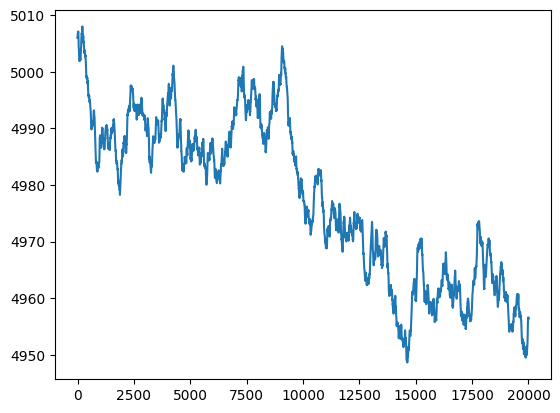

In [50]:
tomatoes1['ema_10'].plot()

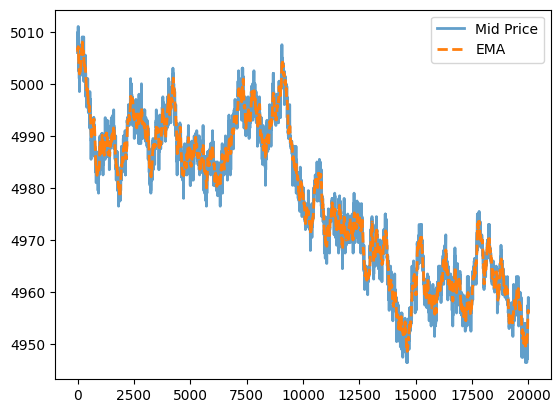

In [56]:
ax = tomatoes1['mid_price'].plot(label='Mid Price', linewidth=2, alpha=0.7)
tomatoes1['ema_10_l2'].plot(ax=ax, label='EMA', linestyle='--', linewidth=2)

ax.legend()

In [43]:
result = (tomatoes1['mid_l1'] == tomatoes1['mid_price']).all()
print(result)

True


In [44]:
tomatoes1['mid_future_10'] = tomatoes1['mid_l1'].shift(-10) 
tomatoes1['price_change'] = tomatoes1['mid_future_10'] - tomatoes1['mid_l1']

# Correlation between your Signal (Dist) and Future Price Change
# If this isn't strongly NEGATIVE, your EMA is wrong.
correlation = tomatoes1['dist'].corr(tomatoes1['price_change'])
correlation

np.float64(-0.3450637789748601)

In [45]:
# Group by signal strength (rounded to 0.5 ticks)
tomatoes1['dist_rounded'] = (tomatoes1['dist'] * 2).round() / 2
analysis = tomatoes1.groupby('dist_rounded')['price_change'].mean()

# The 'Alpha Threshold'
# Find where analysis[dist] > (Average Spread / 2)
print("Optimal Entry Thresholds:")
print(analysis[analysis.abs() > 0.5])

Optimal Entry Thresholds:
dist_rounded
-6.0    6.000000
-5.5    4.222222
-5.0    4.470588
-4.5    3.513514
-4.0    3.481132
-3.5    3.160714
-3.0    2.914286
-2.5    2.809524
-2.0    0.913636
 2.0   -1.578261
 2.5   -2.930108
 3.0   -3.012987
 3.5   -3.403509
 4.0   -3.500000
 4.5   -3.461538
 5.0   -3.888889
Name: price_change, dtype: float64


In [31]:
analysis

dist_rounded
-5.0    5.500000
-4.5    4.192308
-4.0    3.808824
-3.5    3.155738
-3.0    3.351648
-2.5    2.470238
-2.0    1.201439
-1.5    0.368227
-1.0   -0.005769
-0.5   -0.121425
 0.0   -0.016653
 0.5   -0.074870
 1.0   -0.170139
 1.5   -0.363065
 2.0   -1.716216
 2.5   -2.545000
 3.0   -3.376623
 3.5   -3.216216
 4.0   -3.500000
 4.5   -3.666667
Name: price_change, dtype: float64

In [46]:
analysis = tomatoes1.groupby('dist_rounded')['price_change'].std()
analysis

dist_rounded
-6.0         NaN
-5.5    1.348868
-5.0    1.727268
-4.5    1.529735
-4.0    2.242428
-3.5    1.773569
-3.0    2.028727
-2.5    2.077973
-2.0    2.290646
-1.5    1.846934
-1.0    1.784374
-0.5    1.840192
 0.0    1.858728
 0.5    1.883291
 1.0    1.840569
 1.5    1.837577
 2.0    2.125030
 2.5    2.071535
 3.0    1.886542
 3.5    1.960409
 4.0    1.763450
 4.5    2.593755
 5.0    1.867113
Name: price_change, dtype: float64

In [ ]:
tomatoes1['ema_10_l2'] = tomatoes1['mid_price_l2'].ewm(span=10, adjust=False).mean()
tomatoes1['dist_l2'] = tomatoes1['mid_price_l2'] - tomatoes1['ema_10_l2']

tomatoes1['mid_future_10'] = tomatoes1['mid_l1'].shift(-10) 
tomatoes1['price_change_l2'] = tomatoes1['mid_future_10'] - tomatoes1['mid_l1']

# Correlation between your Signal (Dist) and Future Price Change
# If this isn't strongly NEGATIVE, your EMA is wrong.
correlation = tomatoes1['dist_l2'].corr(tomatoes1['price_change_l2'])
correlation

------